In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import pickle
import numpy as np

from aquacrop_slovenia.yield_projections import run_all_projections, get_model_scenario_combinations, \
    compute_period_statistics
from aquacrop_slovenia import config

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"

In [4]:
# Takes about a minute on 28 cores
projections = run_all_projections(LOCATION)
pickle.dump(projections, open(config.RESULTS_DIR / f"projections_v1_{LOCATION}.pkl", "wb"))

Setting up working directory at: E:\aquacrop\proj_jablje_model1_rcp45
Setting up working directory at: E:\aquacrop\proj_jablje_model1_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model2_rcp26
Setting up working directory at: E:\aquacrop\proj_jablje_model2_rcp45
Setting up working directory at: E:\aquacrop\proj_jablje_model2_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model3_rcp45
Setting up working directory at: E:\aquacrop\proj_jablje_model4_rcp26
Setting up working directory at: E:\aquacrop\proj_jablje_model3_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model4_rcp45
Setting up working directory at: E:\aquacrop\proj_jablje_model4_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model5_rcp45
Setting up working directory at: E:\aquacrop\proj_jablje_model5_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model6_rcp85
Setting up working directory at: E:\aquacrop\proj_jablje_model6_rcp45
Running AquaCrop sim

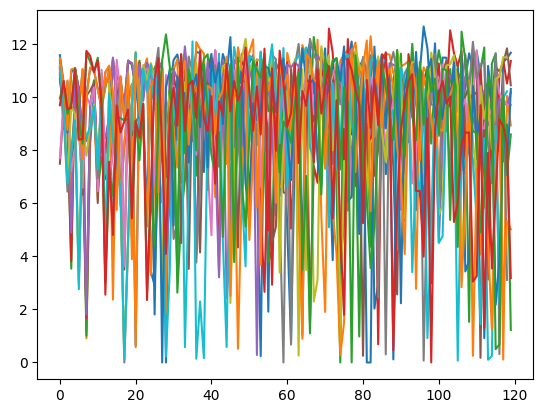

In [5]:
for model, scenario in get_model_scenario_combinations(LOCATION):
    plt.plot(projections[(model, scenario)].loc[:, "Y(dry)"])

In [6]:
projections[("model1", "rcp45")]

,Year1,Y(dry)
0,1981,11.395
1,1982,8.803
2,1983,10.594
3,1984,6.480
4,1985,10.069
...,...,...
115,2096,11.468
116,2097,7.963
117,2098,11.329
118,2099,11.468


In [7]:
for model, scenario in get_model_scenario_combinations(LOCATION):
    print(f"{model}, {scenario}")
    print(compute_period_statistics(projections[(model, scenario)]))
    print()

model1, rcp45
                Mean       Std    Min   Median     Max
Period                                                
1981-2010   8.041333  3.428568  0.000   9.6145  11.435
2011-2040   9.632167  2.878673  0.240  11.0110  11.786
2041-2070   8.578200  3.510813  0.815  10.0590  12.100
2071-2100  10.003433  2.446311  0.916  11.0195  12.668

model1, rcp85
                Mean       Std    Min   Median     Max
Period                                                
1981-2010   8.331733  3.393573  0.574   9.6485  11.464
2011-2040   8.927933  2.681638  0.516   8.9350  12.179
2041-2070  10.255100  2.557910  1.907  11.2875  12.301
2071-2100   9.236000  2.638262  0.112  10.0735  11.356

model2, rcp26
               Mean       Std    Min   Median     Max
Period                                               
1981-2010  9.311667  2.529650  1.012  10.2845  11.441
2011-2040  9.189933  2.574921  2.633  10.1235  11.666
2041-2070  8.827533  3.171454  0.000   9.9510  12.270
2071-2100  9.169733  2.897

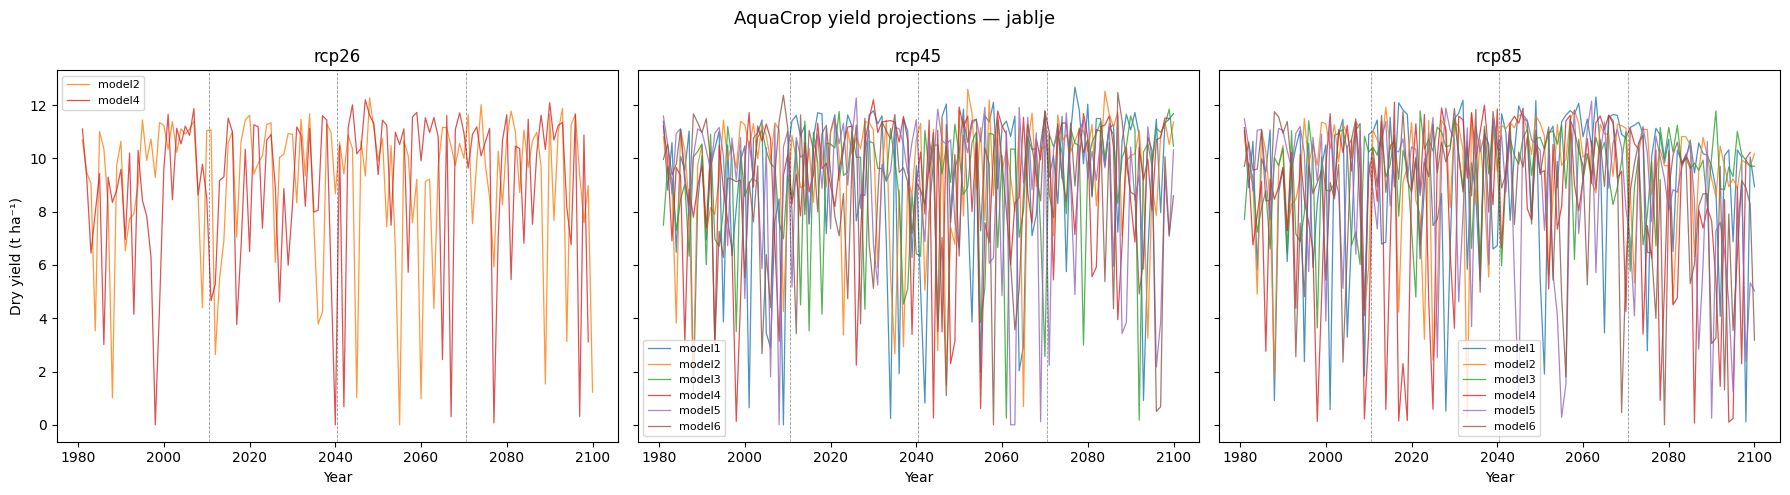

In [8]:
from aquacrop_slovenia.yield_projections import PERIODS

scenarios = sorted({sc for _, sc in projections})
model_names = sorted({model for model, _ in projections})
colors = plt.cm.tab10.colors
period_boundaries = [start for start, _ in PERIODS.values() if start > 1981]

fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5), sharey=True)
if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    for i, model in enumerate(model_names):
        if (model, scenario) not in projections:
            continue
        result = projections[(model, scenario)]
        ax.plot(result["Year1"], result["Y(dry)"], color=colors[i % len(colors)], linewidth=0.9, alpha=0.8, label=model)

    for year in period_boundaries:
        ax.axvline(year - 0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.4)

    ax.set_title(scenario)
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Dry yield (t ha⁻¹)")
fig.suptitle(f"AquaCrop yield projections — {LOCATION}", fontsize=13)
fig.tight_layout()
plt.show()

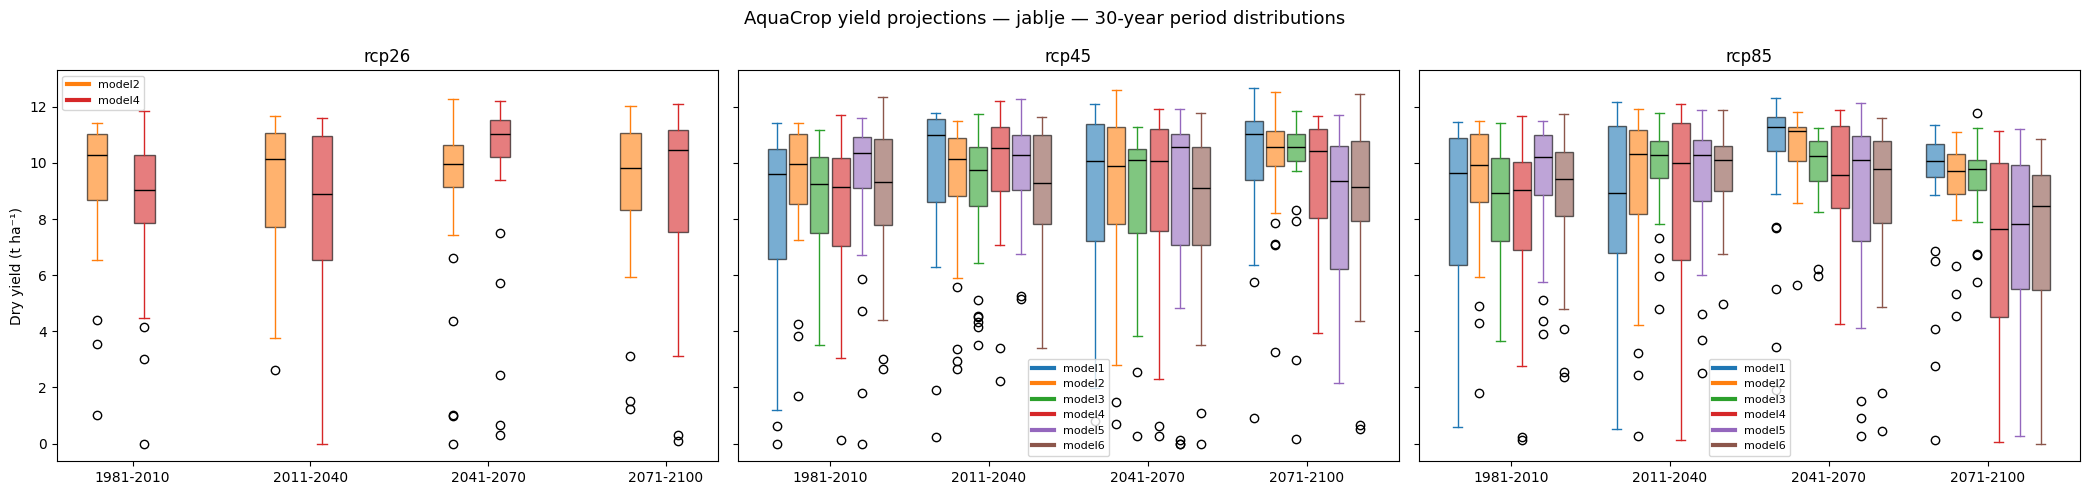

In [9]:
period_labels = list(PERIODS.keys())
n_periods = len(period_labels)
n_models = len(model_names)
group_width = 0.8
box_width = group_width / n_models

fig, axes = plt.subplots(1, len(scenarios), figsize=(7 * len(scenarios), 5), sharey=True)
if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    for i, model in enumerate(model_names):
        if (model, scenario) not in projections:
            continue
        result = projections[(model, scenario)]
        color = colors[i % len(colors)]
        positions, data = [], []
        for j, (label, (start, end)) in enumerate(PERIODS.items()):
            s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"].values
            positions.append(j + (i - (n_models - 1) / 2) * box_width)
            data.append(s)

        bp = ax.boxplot(data, positions=positions, widths=box_width * 0.85,
                        patch_artist=True, manage_ticks=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for key in ("whiskers", "caps", "fliers"):
            for line in bp[key]:
                line.set_color(color)
        for line in bp["medians"]:
            line.set_color("black")
        ax.plot([], [], color=color, linewidth=3, label=model)

    ax.set_xticks(range(n_periods))
    ax.set_xticklabels(period_labels)
    ax.set_title(scenario)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Dry yield (t ha⁻¹)")
fig.suptitle(f"AquaCrop yield projections — {LOCATION} — 30-year period distributions", fontsize=13)
fig.tight_layout()
plt.show()

Setting up working directory at: E:\aquacrop\hist_jablje
Running AquaCrop simulation with project file: E:\aquacrop\hist_jablje\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\hist_jablje\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


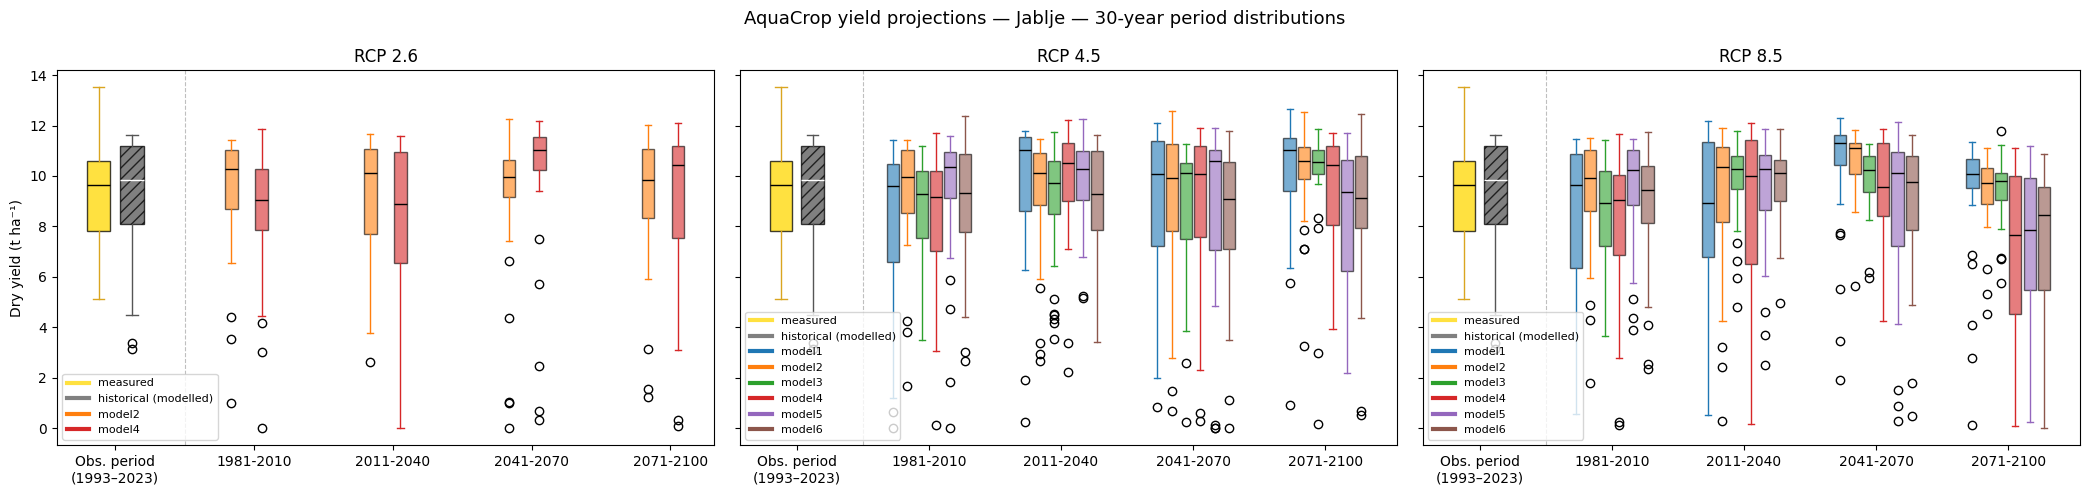

In [10]:
from aquacrop_slovenia.yield_projections import run_historical_simulation
from aquacrop_slovenia.reading_data import get_yield_for_comparison
from aquacrop_slovenia.plots import plot_yield_projections_boxplot_with_hist

hist_results = run_historical_simulation(LOCATION)
obs_yields = get_yield_for_comparison(LOCATION, product="grain", management="A", fertilization="N3")

fig = plot_yield_projections_boxplot_with_hist(projections, LOCATION, hist_results=hist_results, obs_yields=obs_yields)
plt.show()

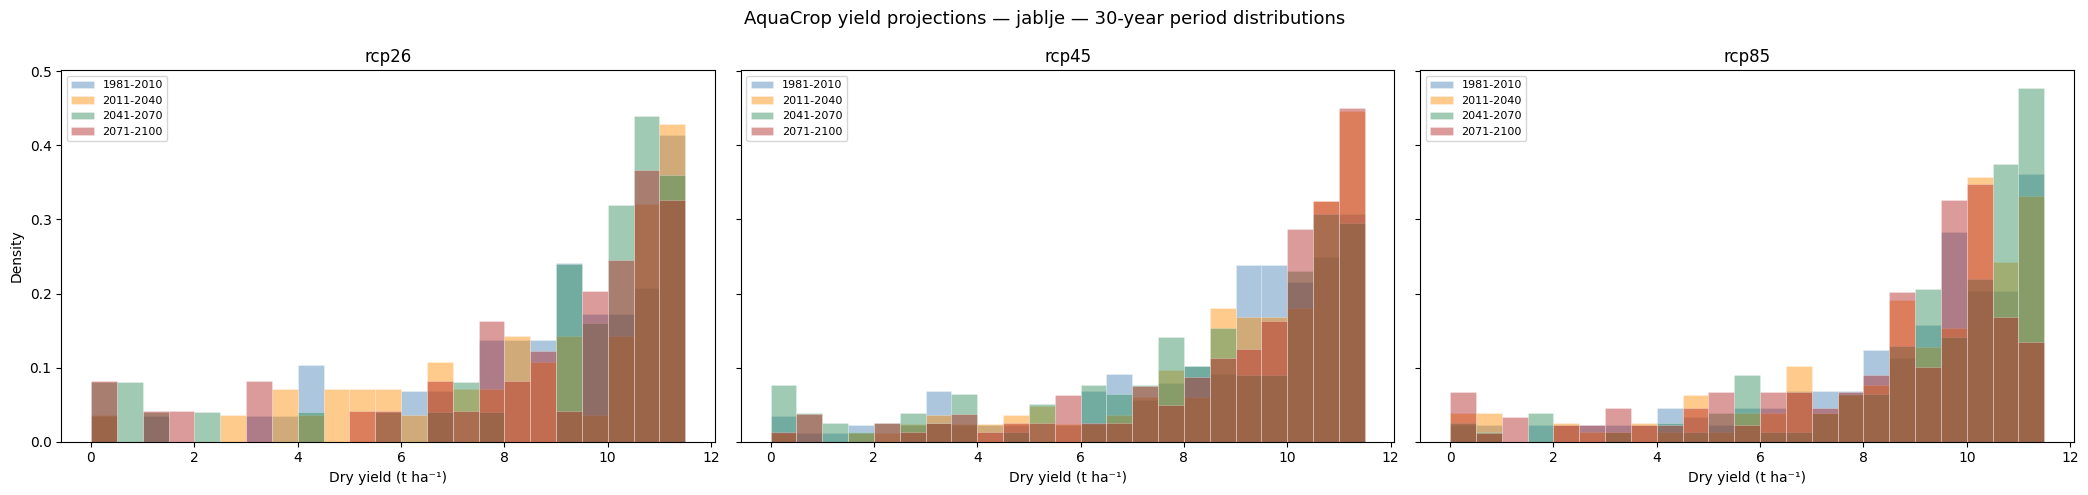

In [11]:
period_colors = {"1981-2010": "steelblue", "2011-2040": "darkorange", "2041-2070": "seagreen", "2071-2100": "firebrick"}

fig, axes = plt.subplots(1, len(scenarios), figsize=(7 * len(scenarios), 5), sharey=True, sharex=True)
if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    for label, (start, end) in PERIODS.items():
        all_yields = []
        for model in model_names:
            if (model, scenario) not in projections:
                continue
            result = projections[(model, scenario)]
            s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"].values
            all_yields.extend(s)
        if all_yields:
            ax.hist(all_yields, bins=np.arange(0, 12, 0.5).tolist(), density=True, alpha=0.45,
                    color=period_colors[label], label=label, edgecolor="white", linewidth=0.4)

    ax.set_title(scenario)
    ax.set_xlabel("Dry yield (t ha⁻¹)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle(f"AquaCrop yield projections — {LOCATION} — 30-year period distributions", fontsize=13)
fig.tight_layout()
plt.show()

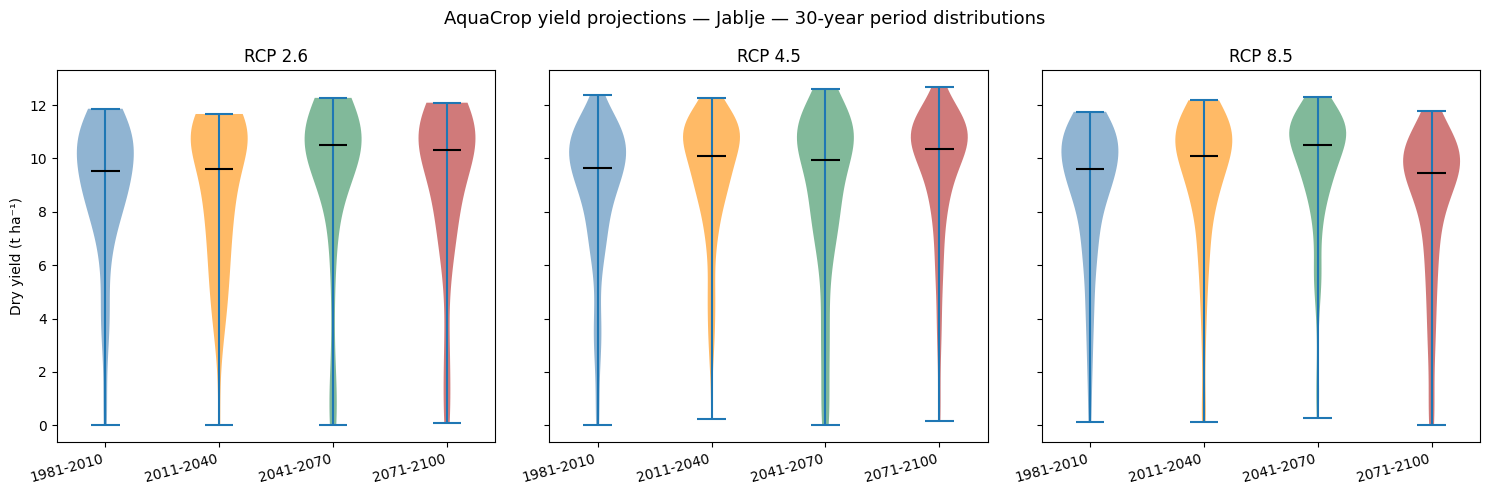

In [12]:
from aquacrop_slovenia.plots import plot_yield_projections_by_period

fig = plot_yield_projections_by_period(projections, LOCATION)
plt.show()

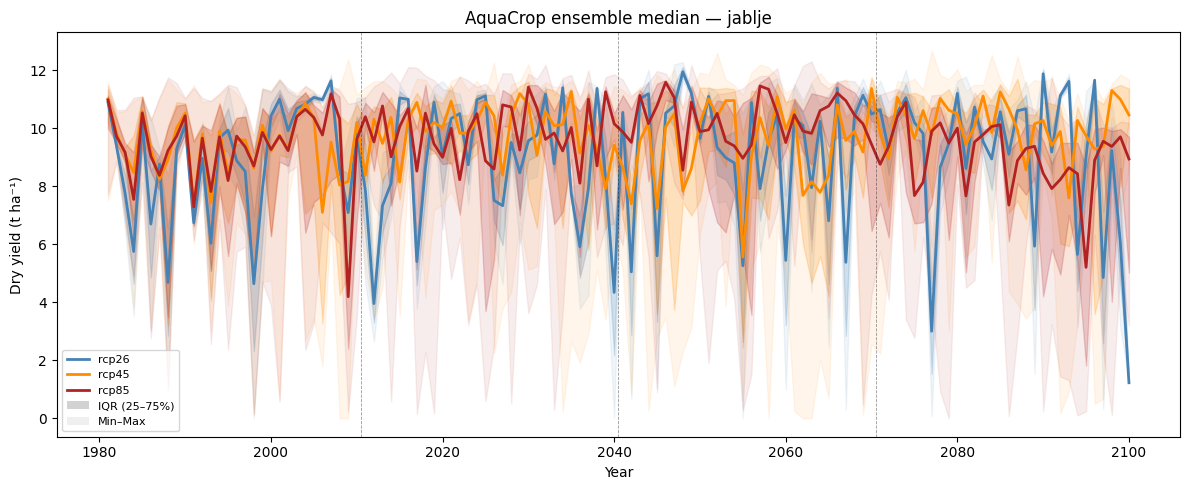

In [13]:
import pandas as pd
from matplotlib.patches import Patch

scenario_colors = {"rcp26": "steelblue", "rcp45": "darkorange", "rcp85": "firebrick"}

fig, ax = plt.subplots(figsize=(12, 5))

for scenario in scenarios:
    frames = [
        projections[(model, scenario)].set_index("Year1")["Y(dry)"].rename(model)
        for model in model_names
        if (model, scenario) in projections
    ]
    ensemble = pd.concat(frames, axis=1)
    color = scenario_colors.get(scenario, "gray")

    ax.fill_between(ensemble.index, ensemble.min(axis=1), ensemble.max(axis=1),
                    alpha=0.08, color=color)
    ax.fill_between(ensemble.index, ensemble.quantile(0.25, axis=1), ensemble.quantile(0.75, axis=1),
                    alpha=0.2, color=color)
    ax.plot(ensemble.index, ensemble.median(axis=1), color=color, linewidth=2, label=scenario)

for year in period_boundaries:
    ax.axvline(year - 0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
handles += [
    Patch(facecolor="gray", alpha=0.35, label="IQR (25–75%)"),
    Patch(facecolor="gray", alpha=0.12, label="Min–Max"),
]
ax.legend(handles=handles, fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title(f"AquaCrop ensemble median — {LOCATION}")
fig.tight_layout()
plt.show()